In [ ]:
# Установка библиотек
!pip install phik

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from phik import phik_matrix

warnings.filterwarnings("ignore")

In [3]:
# Фиксация random_state для воспроизводимости
RANDOM_STATE = 42

In [4]:
# Выгрузка данных в переменную df
df = pd.read_excel('dataset_ai_human.xlsx')

In [5]:
df.head()

,Тема,Предмет,Текст,Генерация,word_count,avg_word_length,avg_sentence_length,TTR,MSTTR,hapax_ratio,...,CCONJ,X,AUX,SYM,INTJ,punctuation_ratio,digit_ratio,flesch_ru,gunning_fog_ru,herdan_c
0,"«Погоня за прибылью — единственный способ, при...",S,Позвольте мне обратиться к одному из фундамент...,0,435,6.921659,17.360000,0.632184,0.947937,0.460829,...,0.032015,0.001883,0.000000,0.0,0.0,0.216092,0.000000,5.500875,30.238664,0.956306
1,"«Погоня за прибылью — единственный способ, при...",S,Ф. Хайек в своём высказывании поднимает пробле...,1,308,7.210526,13.818182,0.649351,0.888571,0.452459,...,0.032520,0.000000,0.005420,0.0,0.0,0.207792,0.012987,10.152943,28.948325,0.958728
2,"«Власть над собой — высшая власть, а свои стра...",S,Власть над собой — высшая власть: философский ...,0,283,6.448029,15.500000,0.681979,0.886667,0.562278,...,0.041885,0.000000,0.000000,0.0,0.0,0.363958,0.000000,25.917500,26.200000,0.935399
3,"«Власть над собой — высшая власть, а свои стра...",S,"Данным высказыванием Толстой хотел сказать, чт...",1,361,6.463687,16.272727,0.603878,0.905000,0.435754,...,0.045455,0.000000,0.004785,0.0,0.0,0.166205,0.000000,26.514520,25.739860,0.945499
4,«Человек создан для действия. Не действовать и...,S,Человек создан для действия: философское осмыс...,0,257,6.223529,15.000000,0.688716,0.900000,0.545098,...,0.040580,0.008696,0.002899,0.0,0.0,0.346304,0.007782,32.655319,24.645418,0.945634


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3820 entries, 0 to 3819
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Тема                 3820 non-null   object 
 1   Предмет              3820 non-null   object 
 2   Текст                3817 non-null   object 
 3   Генерация            3820 non-null   int64  
 4   word_count           3820 non-null   int64  
 5   avg_word_length      3820 non-null   float64
 6   avg_sentence_length  3820 non-null   float64
 7   TTR                  3820 non-null   float64
 8   MSTTR                3820 non-null   float64
 9   hapax_ratio          3820 non-null   float64
 10  yule                 3820 non-null   float64
 11  function_words       3820 non-null   float64
 12  shannon_entropy      3820 non-null   float64
 13  simpson_index        3820 non-null   float64
 14  VERB                 3820 non-null   float64
 15  PRON                 3820 non-null   f

Признаки `Тема` и `Текст` будут удалены, так как не несут предсказательной важности для модели

Далее, после анализа, будет удален признак `Предмет`

Признак `X` и `SYM` также создают шум

In [7]:
columns_to_drop = ['Тема', 'Текст', 'X', 'SYM']
df = df.drop(columns=columns_to_drop)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3820 entries, 0 to 3819
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Предмет              3820 non-null   object 
 1   Генерация            3820 non-null   int64  
 2   word_count           3820 non-null   int64  
 3   avg_word_length      3820 non-null   float64
 4   avg_sentence_length  3820 non-null   float64
 5   TTR                  3820 non-null   float64
 6   MSTTR                3820 non-null   float64
 7   hapax_ratio          3820 non-null   float64
 8   yule                 3820 non-null   float64
 9   function_words       3820 non-null   float64
 10  shannon_entropy      3820 non-null   float64
 11  simpson_index        3820 non-null   float64
 12  VERB                 3820 non-null   float64
 13  PRON                 3820 non-null   float64
 14  ADP                  3820 non-null   float64
 15  NUM                  3820 non-null   f

In [9]:
df.rename(columns={'Генерация': 'ai_human', 'Предмет': 'subject', 'flesch_ru': 'flesch', 'gunning_fog_ru': 'gunning_fog'}, inplace=True)

Данные были успешно выгружены. Датасет `dataset_ai_human` содержит 32 столбца и 3820 строк

## Исследовательский анализ данных (EDA)

### Описание датасета

Датасет представляет собой корпус текстов, размеченных по признаку происхождения (человеческий или сгенерированный), с набором стилометрических, лексических, синтаксических и информационных характеристик

**Метаданные**:
- `subject` — предметная область текста:
   - S — обществознание
   - R — русский язык

**Целевая переменная** — `ai_human`:
   - 1 — текст написан человеком
   - 0 — текст сгенерирован моделью

**Количественные характеристики текста**:
- `word_count` — количество слов в тексте
- `avg_word_length` — средняя длина слова (в символах)
- `avg_sentence_length` — средняя длина предложения (в словах)

**Лексическое разнообразие**:
- `TTR` — Type-Token Ratio (доля уникальных слов)
- `MSTTR` — усредненный TTR по сегментам текста
- `hapax_ratio` — доля слов (лемм), встречающихся один раз
- `herdan_c` — логарифмическая мера лексического разнообразия

**Частотные и распределительные метрики**:
- `yule` — индекс Юла (степень повторяемости слов)
- `shannon_entropy` — энтропия Шеннона (равномерность распределения слов)
- `simpson_index` — индекс Симпсона (вероятность совпадения слов)

**Морфологические признаки (распределение частей речи)**:

Доли частей речи в тексте:
- `VERB` — глаголы
- `PRON` — местоимения
- `ADP` — предлоги
- `NUM` — числительные
- `ADJ` — прилагательные
- `NOUN` — существительные
- `PUNCT` — знаки препинания
- `PROPN` — имена собственные
- `DET` — детерминативы
- `SCONJ` — подчинительные союзы
- `ADV` — наречия
- `PART` — частицы
- `CCONJ` — сочинительные союзы
- `AUX` — вспомогательные глаголы
- `INTJ` — междометия
- `function_words` — доля служебных слов (предлоги, союзы, частицы, местоимения)

**Поверхностные признаки**:
- `punctuation_ratio` — доля знаков препинания (относительно количества слов)
- `digit_ratio` — доля цифр в тексте

**Метрики читаемости**:
- `flesch_ru` — индекс читаемости Флеша
- `gunning_fog_ru` — индекс сложности текста (Gunning Fog)

#### Анализ целевой переменной

In [10]:
# Проверка на уникальные значение (должен быть бинарный признак)
df['ai_human'].unique()

array([0, 1], dtype=int64)

In [11]:
# Доля генерации
df['ai_human'].value_counts(normalize=True).sort_values(ascending=False)

0    0.5
1    0.5
Name: ai_human, dtype: float64

In [12]:
df['ai_human'].value_counts(normalize=False).sort_values(ascending=False)

0    1910
1    1910
Name: ai_human, dtype: int64

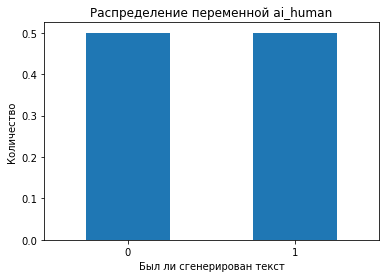

In [13]:
# Распределение целевой переменной
df['ai_human'].value_counts(normalize=True).sort_values(ascending=False).plot(
               kind='bar',
               rot=0, 
               legend=False, 
               title=f'Распределение переменной ai_human'
)

# Оформление графика
plt.xlabel('Был ли сгенерирован текст')
plt.ylabel('Количество')
plt.show()

Дисбаланс отсутствует, данные разделены поровну

#### Анализ переменной `subject`

In [14]:
# Доля генерации
df['subject'].value_counts(normalize=True).sort_values(ascending=False)

R    0.628272
S    0.371728
Name: subject, dtype: float64

In [15]:
df['subject'].value_counts(normalize=False).sort_values(ascending=False)

R    2400
S    1420
Name: subject, dtype: int64

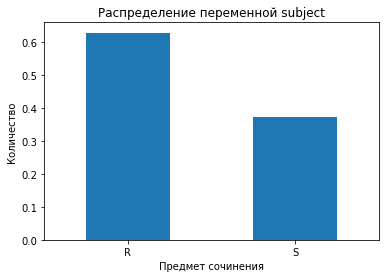

In [16]:
# Распределение целевой переменной
df['subject'].value_counts(normalize=True).sort_values(ascending=False).plot(
               kind='bar',
               rot=0, 
               legend=False, 
               title=f'Распределение переменной subject'
)

# Оформление графика
plt.xlabel('Предмет сочинения')
plt.ylabel('Количество')
plt.show()

In [17]:
# Распределение данных по subject и столбцу ai_human
df_sub_ai_h = df.groupby(['subject', 'ai_human']).size().unstack().fillna(0)
df_sub_ai_h

ai_human,0,1
subject,,
R,1200,1200
S,710,710


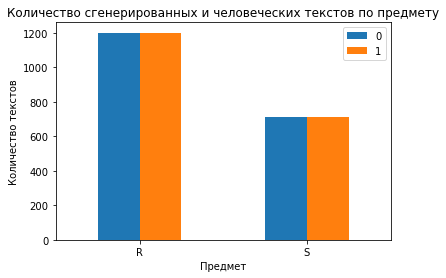

In [18]:
df_sub_ai_h.plot(kind='bar')

plt.title('Количество сгенерированных и человеческих текстов по предмету') 
plt.ylabel('Количество текстов') 
plt.xlabel('Предмет')
plt.xticks(rotation=0) 
plt.legend()

plt.show()

Тексты по предметам распределены одинаково

63% - русский

37% - обществознание

In [19]:
# Удаление бесполезных признаков
columns_to_drop = ['subject']
df = df.drop(columns=columns_to_drop)

In [20]:
# Вывод количества пропусков
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

'Пропусков в данных нет'

#### Анализ выбросов и распределений

In [21]:
# Функция для вывода статистики по столбцу и построения ящиков с усами и гистограмм
def plot_box_hist(df, column, bins=30):
    print(f"Статистика для признака {column}")
    print(df[column].describe())
    sns.set_theme(style="darkgrid")
    
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                         gridspec_kw={"height_ratios": (.15, .85)})
    
    sns.boxplot(df[column], orient="h", ax=ax_box)
    sns.histplot(data=df, x=column, ax=ax_hist, bins=bins)
    ax_box.set(xlabel='')
    plt.suptitle(f'Распределение {column}')
    plt.show()

Статистика для признака word_count
count    3820.000000
mean      389.850262
std        59.140108
min         1.000000
25%       357.000000
50%       385.000000
75%       416.000000
max      1210.000000
Name: word_count, dtype: float64


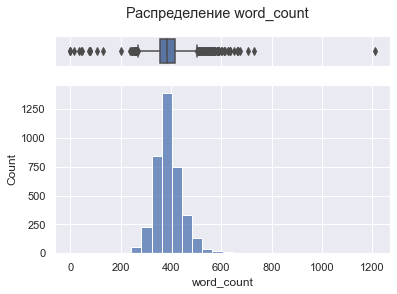

In [22]:
plot_box_hist(df, 'word_count')

In [23]:
Q1 = 357
Q3 = 416

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper

(268.5, 504.5)

In [24]:
outliers = df[
    (df["word_count"] < lower) | 
    (df["word_count"] > upper)
]

len(outliers)

135

In [25]:
len(outliers) / len(df)

0.03534031413612566

Для выявления аномальных значений использовался межквартильный размах. Объекты, выходящие за пределы Q1−1.5⋅IQR; Q3+1.5⋅IQR, рассматриваются как выбросы и исключаются из анализа

In [26]:
df = df[
    (df["word_count"] >= lower) & 
    (df["word_count"] <= upper)
]

In [27]:
# Доля генерации
df['ai_human'].value_counts(normalize=True).sort_values(ascending=False)

1    0.518046
0    0.481954
Name: ai_human, dtype: float64

In [28]:
df['ai_human'].value_counts(normalize=False).sort_values(ascending=False)

1    1909
0    1776
Name: ai_human, dtype: int64

После фильтрации осталось 3685 текстов, из них 1909 человеческих, 1776 - сгенерированных

Статистика для признака word_count
count    3685.000000
mean      387.176391
std        45.528670
min       269.000000
25%       357.000000
50%       384.000000
75%       413.000000
max       504.000000
Name: word_count, dtype: float64


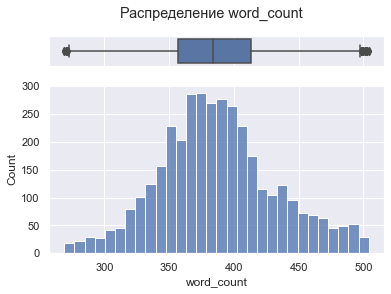

In [29]:
plot_box_hist(df, 'word_count')

Распределение по количеству слов близко к нормальному. Минимальное количество слов - 269, максимальное - 504. Среднее - 387, медиана - 384

Ошибки в количестве слов связаны с ошибкой копирования текстов, неправильным вводом

Статистика для признака avg_word_length
count    3685.000000
mean        6.185800
std         0.531735
min         4.747159
25%         5.800546
50%         6.113821
75%         6.512644
max         8.169065
Name: avg_word_length, dtype: float64


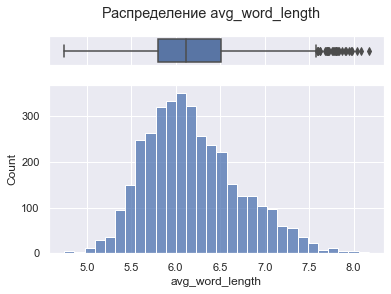

In [30]:
plot_box_hist(df, 'avg_word_length')

Статистика для признака avg_sentence_length
count    3685.000000
mean       17.259195
std         3.405917
min         7.500000
25%        15.000000
50%        16.909091
75%        19.090909
max        33.833333
Name: avg_sentence_length, dtype: float64


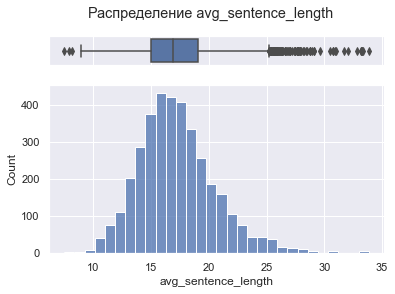

In [31]:
plot_box_hist(df, 'avg_sentence_length')

Статистика для признака TTR
count    3685.000000
mean        0.603169
std         0.056539
min         0.396594
25%         0.563265
50%         0.602857
75%         0.644385
max         0.771930
Name: TTR, dtype: float64


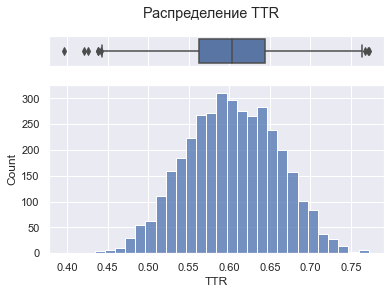

In [32]:
plot_box_hist(df, 'TTR')

Статистика для признака MSTTR
count    3685.000000
mean        0.888532
std         0.031092
min         0.746667
25%         0.867295
50%         0.891429
75%         0.912500
max         0.960000
Name: MSTTR, dtype: float64


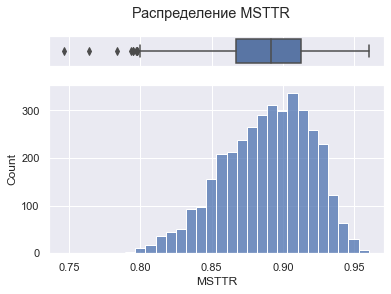

In [33]:
plot_box_hist(df, 'MSTTR')

Статистика для признака hapax_ratio
count    3685.000000
mean        0.439053
std         0.068629
min         0.203980
25%         0.389744
50%         0.438119
75%         0.488304
max         0.662050
Name: hapax_ratio, dtype: float64


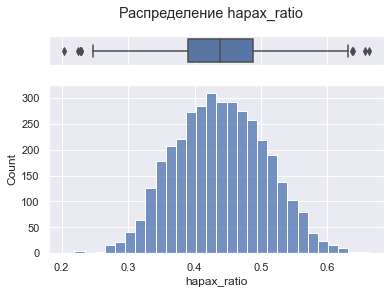

In [34]:
plot_box_hist(df, 'hapax_ratio')

Статистика для признака yule
count    3685.000000
mean       67.521720
std        15.609639
min        27.474567
25%        56.360709
50%        66.009176
75%        77.166407
max       157.026118
Name: yule, dtype: float64


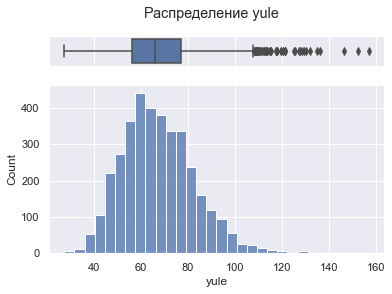

In [35]:
plot_box_hist(df, 'yule')

Статистика для признака function_words
count    3685.000000
mean        0.269169
std         0.038988
min         0.133779
25%         0.244552
50%         0.268786
75%         0.294872
max         0.402402
Name: function_words, dtype: float64


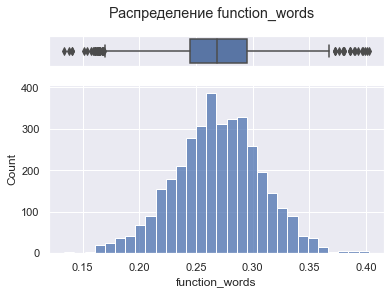

In [36]:
plot_box_hist(df, 'function_words')

Статистика для признака shannon_entropy
count    3685.000000
mean        7.415323
std         0.209265
min         6.542512
25%         7.270752
50%         7.407328
75%         7.567522
max         8.020955
Name: shannon_entropy, dtype: float64


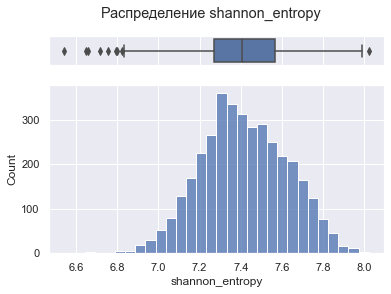

In [37]:
plot_box_hist(df, 'shannon_entropy')

Статистика для признака simpson_index
count    3685.000000
mean        0.010175
std         0.001723
min         0.005940
25%         0.008950
50%         0.009956
75%         0.011203
max         0.019359
Name: simpson_index, dtype: float64


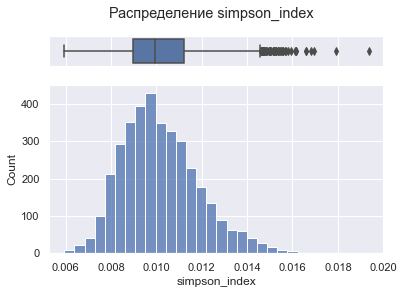

In [38]:
plot_box_hist(df, 'simpson_index')

Статистика для признака VERB
count    3685.000000
mean        0.119917
std         0.018380
min         0.059896
25%         0.107356
50%         0.118980
75%         0.132184
max         0.189409
Name: VERB, dtype: float64


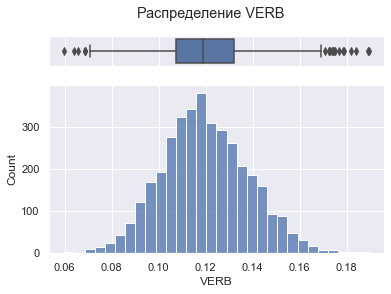

In [39]:
plot_box_hist(df, 'VERB')

Статистика для признака PRON
count    3685.000000
mean        0.045276
std         0.018600
min         0.002288
25%         0.032015
50%         0.043912
75%         0.057395
max         0.120805
Name: PRON, dtype: float64


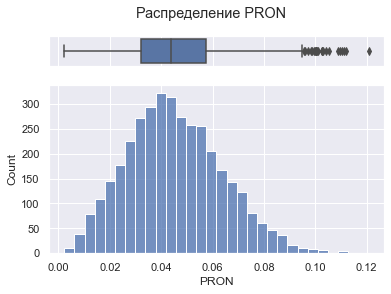

In [40]:
plot_box_hist(df, 'PRON')

Статистика для признака ADP
count    3685.000000
mean        0.086285
std         0.013865
min         0.041899
25%         0.076923
50%         0.086172
75%         0.095588
max         0.134529
Name: ADP, dtype: float64


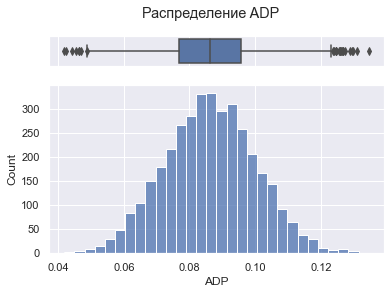

In [41]:
plot_box_hist(df, 'ADP')

Статистика для признака NUM
count    3685.000000
mean        0.005455
std         0.004797
min         0.000000
25%         0.002151
50%         0.004376
75%         0.007557
max         0.041958
Name: NUM, dtype: float64


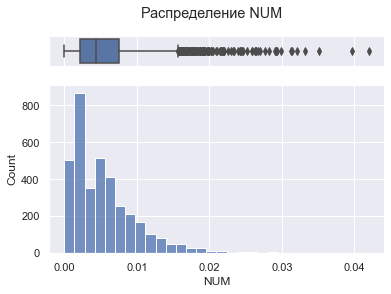

In [42]:
plot_box_hist(df, 'NUM')

Статистика для признака ADJ
count    3685.000000
mean        0.097735
std         0.024123
min         0.037778
25%         0.080235
50%         0.095745
75%         0.112500
max         0.200000
Name: ADJ, dtype: float64


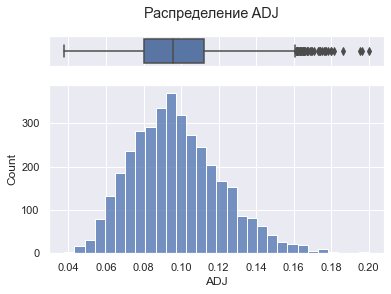

In [43]:
plot_box_hist(df, 'ADJ')

Статистика для признака NOUN
count    3685.000000
mean        0.274887
std         0.042032
min         0.142276
25%         0.245050
50%         0.273504
75%         0.302521
max         0.429851
Name: NOUN, dtype: float64


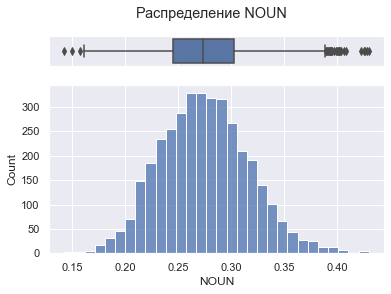

In [44]:
plot_box_hist(df, 'NOUN')

Статистика для признака PUNCT
count    3685.000000
mean        0.176806
std         0.023029
min         0.098291
25%         0.161148
50%         0.176471
75%         0.191579
max         0.278978
Name: PUNCT, dtype: float64


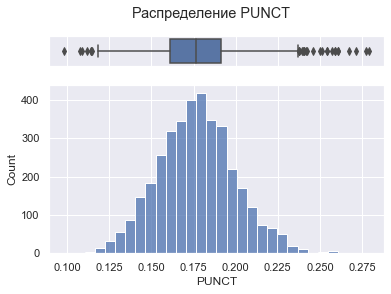

In [45]:
plot_box_hist(df, 'PUNCT')

Статистика для признака PROPN
count    3685.000000
mean        0.029263
std         0.014568
min         0.000000
25%         0.018824
50%         0.027311
75%         0.037736
max         0.109375
Name: PROPN, dtype: float64


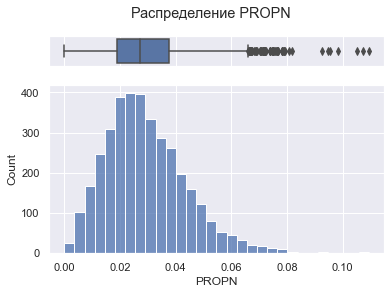

In [46]:
plot_box_hist(df, 'PROPN')

Статистика для признака DET
count    3685.000000
mean        0.032525
std         0.011518
min         0.002151
25%         0.024528
50%         0.031401
75%         0.039861
max         0.087576
Name: DET, dtype: float64


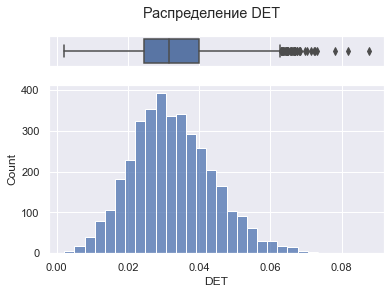

In [47]:
plot_box_hist(df, 'DET')

Статистика для признака SCONJ
count    3685.000000
mean        0.021026
std         0.007849
min         0.000000
25%         0.015487
50%         0.020408
75%         0.025943
max         0.059642
Name: SCONJ, dtype: float64


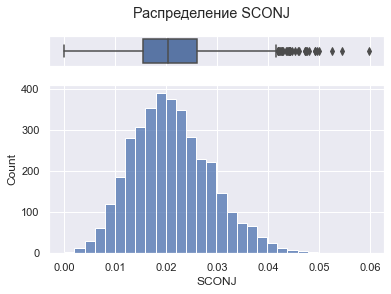

In [48]:
plot_box_hist(df, 'SCONJ')

Статистика для признака ADV
count    3685.000000
mean        0.036745
std         0.012548
min         0.005556
25%         0.027855
50%         0.035581
75%         0.044597
max         0.103070
Name: ADV, dtype: float64


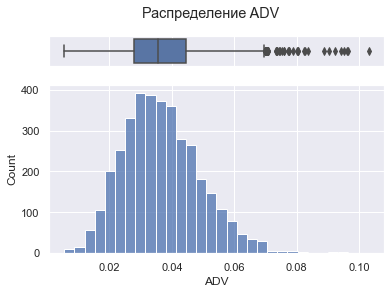

In [49]:
plot_box_hist(df, 'ADV')

Статистика для признака PART
count    3685.000000
mean        0.028499
std         0.012426
min         0.000000
25%         0.019355
50%         0.027714
75%         0.036364
max         0.076503
Name: PART, dtype: float64


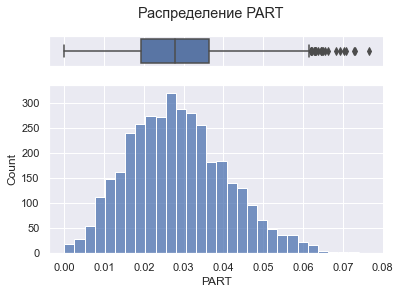

In [50]:
plot_box_hist(df, 'PART')

Статистика для признака CCONJ
count    3685.000000
mean        0.040266
std         0.011400
min         0.006608
25%         0.032075
50%         0.039683
75%         0.048055
max         0.079208
Name: CCONJ, dtype: float64


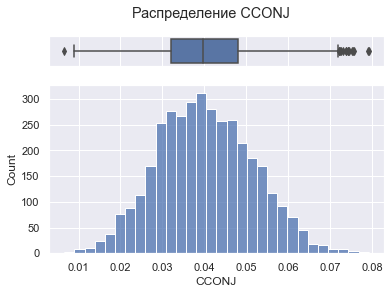

In [51]:
plot_box_hist(df, 'CCONJ')

Статистика для признака AUX
count    3685.000000
mean        0.004766
std         0.004490
min         0.000000
25%         0.001890
50%         0.003992
75%         0.006957
max         0.036957
Name: AUX, dtype: float64


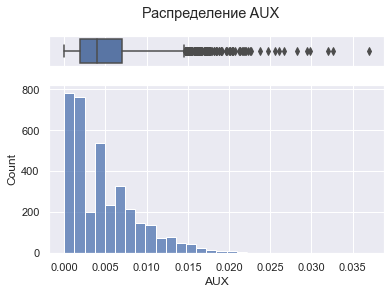

In [52]:
plot_box_hist(df, 'AUX')

Статистика для признака INTJ
count    3685.000000
mean        0.000026
std         0.000247
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.004525
Name: INTJ, dtype: float64


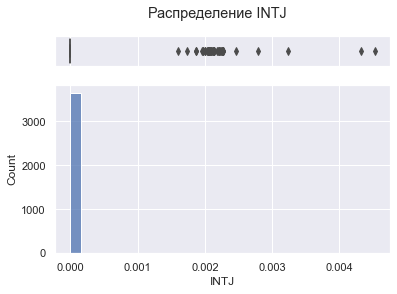

In [53]:
plot_box_hist(df, 'INTJ')

Удаляем междометие, не повлияет на предсказательную способность модели

In [54]:
# Удаление бесполезных признаков
columns_to_drop = ['INTJ']
df = df.drop(columns=columns_to_drop)

Статистика для признака punctuation_ratio
count    3685.000000
mean        0.223458
std         0.035555
min         0.111374
25%         0.200000
50%         0.222222
75%         0.245333
max         0.391414
Name: punctuation_ratio, dtype: float64


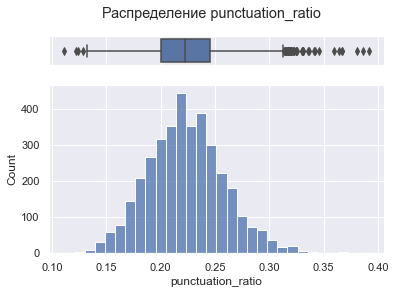

In [55]:
plot_box_hist(df, 'punctuation_ratio')

Статистика для признака digit_ratio
count    3685.000000
mean        0.006927
std         0.015265
min         0.000000
25%         0.000000
50%         0.000000
75%         0.009259
max         0.167102
Name: digit_ratio, dtype: float64


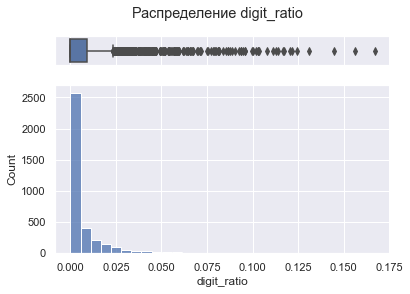

In [56]:
plot_box_hist(df, 'digit_ratio')

Надо проверить признак `digit_ratio` на важность, можно будет сделать его бинарным

Статистика для признака flesch
count    3685.000000
mean       27.441182
std        16.036544
min       -31.422706
25%        17.813832
50%        29.186136
75%        39.406070
max        73.553681
Name: flesch, dtype: float64


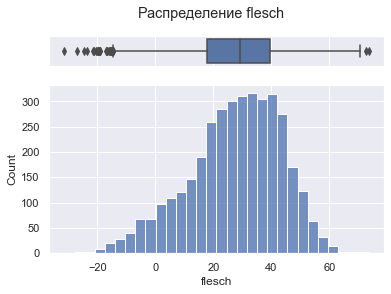

In [57]:
plot_box_hist(df, 'flesch')

Статистика для признака gunning_fog
count    3685.000000
mean       26.466065
std         3.296457
min        15.600920
25%        24.072672
50%        26.304839
75%        28.571429
max        38.231951
Name: gunning_fog, dtype: float64


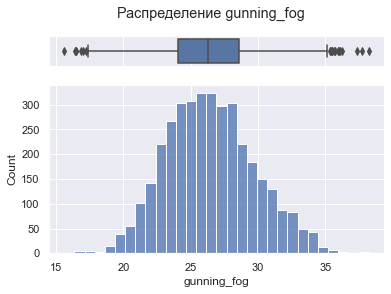

In [58]:
plot_box_hist(df, 'gunning_fog')

Статистика для признака herdan_c
count    3685.000000
mean        0.938623
std         0.011484
min         0.876085
25%         0.931432
50%         0.938728
75%         0.945853
max         0.977453
Name: herdan_c, dtype: float64


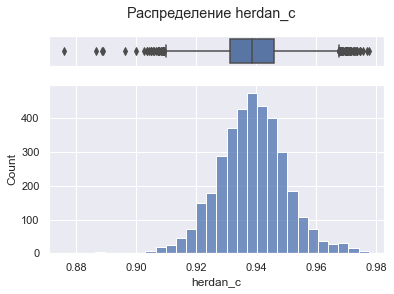

In [59]:
plot_box_hist(df, 'herdan_c')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3685 entries, 0 to 3819
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ai_human             3685 non-null   int64  
 1   word_count           3685 non-null   int64  
 2   avg_word_length      3685 non-null   float64
 3   avg_sentence_length  3685 non-null   float64
 4   TTR                  3685 non-null   float64
 5   MSTTR                3685 non-null   float64
 6   hapax_ratio          3685 non-null   float64
 7   yule                 3685 non-null   float64
 8   function_words       3685 non-null   float64
 9   shannon_entropy      3685 non-null   float64
 10  simpson_index        3685 non-null   float64
 11  VERB                 3685 non-null   float64
 12  PRON                 3685 non-null   float64
 13  ADP                  3685 non-null   float64
 14  NUM                  3685 non-null   float64
 15  ADJ                  3685 non-null   f

После исследовательского анализа осталось 30 столбцов и 3685 строк

#### Корреляция

In [61]:
# Создание корреляционной матрицы
all_features = ['word_count', 'avg_word_length', 'avg_sentence_length', 'TTR', 'MSTTR',
                'hapax_ratio', 'yule', 'function_words', 'shannon_entropy', 'simpson_index', 
                'VERB', 'PRON', 'ADP', 'NUM', 'ADJ', 'NOUN', 'PUNCT', 'PROPN', 'DET', 'SCONJ', 
                'ADV', 'PART', 'CCONJ', 'AUX', 'punctuation_ratio', 'digit_ratio', 
                'flesch', 'gunning_fog', 'herdan_c', 'ai_human']

correlation_matrix = df[all_features].phik_matrix()

print('Корреляционная матрица с коэффициентом phi_k для переменной ai_human')
correlation_matrix.loc[correlation_matrix.index != 'ai_human'][['ai_human']].sort_values(by='ai_human', ascending=False)

interval columns not set, guessing: ['word_count', 'avg_word_length', 'avg_sentence_length', 'TTR', 'MSTTR', 'hapax_ratio', 'yule', 'function_words', 'shannon_entropy', 'simpson_index', 'VERB', 'PRON', 'ADP', 'NUM', 'ADJ', 'NOUN', 'PUNCT', 'PROPN', 'DET', 'SCONJ', 'ADV', 'PART', 'CCONJ', 'AUX', 'punctuation_ratio', 'digit_ratio', 'flesch', 'gunning_fog', 'herdan_c', 'ai_human']
Корреляционная матрица с коэффициентом phi_k для переменной ai_human


,ai_human
MSTTR,0.816753
TTR,0.755320
hapax_ratio,0.743048
CCONJ,0.650040
shannon_entropy,0.607842
PRON,0.575790
avg_sentence_length,0.490306
VERB,0.481549
AUX,0.478331
yule,0.474876


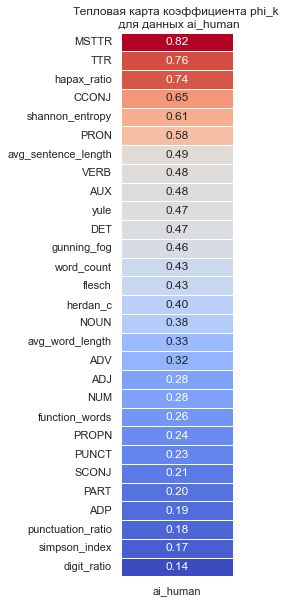

In [62]:
# Строим тепловую карту
plt.figure(figsize=(2, 10))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'ai_human'][['ai_human']].sort_values(by='ai_human', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
           )

plt.title('Тепловая карта коэффициента phi_k \n для данных ai_human')
plt.show()

ТОП-признаки:
- `MSTTR` - 0.82
- `TTR` - 0.76
- `hapax_ratio` - 0.74

Эти признаки указывают на лексическое разнообразие. Это значит, что AI и человек сильно различаются по:
- разнообразию слов
- повторяемости
- распределению лексики

Также сильными признаками являются:
- `CCONJ` - 0.65
- `shannon_entropy` - 0.61
- `PRON` - 0.58

Средняя сила:
- `avg_sentence_length` - 0.49
- `VERB` - 0.48
- `AUX` - 0.48
- `yule` - 0.47
- `DET` - 0.47
- `gunning fog` – 0.46
-`word_count` - 0.43
- `flesch` - 0.43
- `herdan_C` - 0.4
- `NOUN` - 0.38
- `avg_word_length` - 0.33
- `ADV` - 0.32
- `ADJ` - 0.28
- `NUM` - 0.28
- `function_words` - 0.26
- `PROPN` - 0.24
- `PUNCT` - 0.23
- `SCONJ` - 0.21

Слабые признаки:
- `PART` - 0.2
- `ADP` - 0.19
- `punctuation_ratio` - 0.18
- `simpson_index` - 0.17
- `digit_ratio` - 0.14

Слабые признаки можно удалить

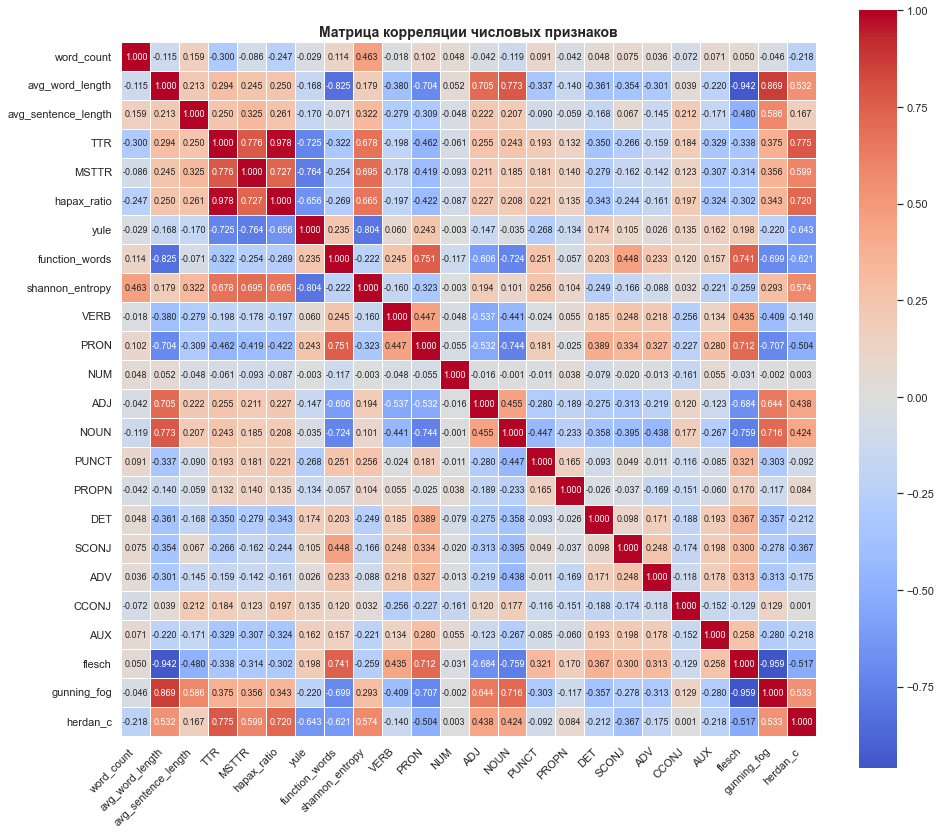

In [63]:
numeric_features = ['word_count', 'avg_word_length', 'avg_sentence_length', 'TTR', 'MSTTR',
                'hapax_ratio', 'yule', 'function_words', 'shannon_entropy', 'VERB', 'PRON', 
                'NUM', 'ADJ', 'NOUN', 'PUNCT', 'PROPN', 'DET', 'SCONJ', 'ADV', 'CCONJ', 'AUX', 
                'flesch', 'gunning_fog', 'herdan_c']

df_numeric = df[numeric_features].copy()
df_numeric_clean = df_numeric.dropna()

if len(df_numeric_clean) > 0:
    corr_matrix_full = df_numeric_clean.corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix_full, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, fmt='.3f',
                annot_kws={'size': 9})
    plt.title('Матрица корреляции числовых признаков', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

В ходе анализа корреляционной матрицы числовых признаков была выявлена высокая степень мультиколлинеарности между рядом показателей, характеризующих лексическое разнообразие и читаемость текста. Это свидетельствует о том, что данные признаки несут дублирующую информацию и могут быть исключены без существенной потери качества модели.

- `hapax_ratio` можно удалить, поскольку его корреляция с `TTR` = 0.978, что указывает на практически полное дублирование информации (оба признака отражают долю уникальных слов в тексте);
- `herdan_c` можно удалить, поскольку его корреляция с `TTR` = 0.775, с `MSTTR` = 0.599 и с `hapax_ratio` = 0.72, что свидетельствует о высокой зависимости и принадлежности к той же группе метрик лексического разнообразия;
- `shannon_entropy` можно удалить, поскольку его корреляция с `TTR` = 0.678, с MSTTR = 0.695 и с `hapax_ratio` = 0.665, что также указывает на дублирование информации о распределении слов в тексте;
- `flesch` можно удалить, поскольку его корреляция с `gunning_fog` = −0.959, что означает практически линейную зависимость (обе метрики измеряют читаемость текста, но с противоположной шкалой);
- `TTR` может быть удален при использовании `MSTTR`, поскольку их корреляция составляет 0.776, а показатель MSTTR считается более устойчивым к длине текста;
- признаки `TTR`, `MSTTR`, `hapax_ratio`, `herdan_c` и `shannon_entropy` образуют группу взаимосвязанных показателей, описывающих лексическое разнообразие, поэтому целесообразно оставить только 1–2 наиболее репрезентативных признака из данной группы.